```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`收入波动问题 V：资产随机收益 <single: The Income Fluctuation Problem V: Stochastic Returns on Assets>`

```{include} _admonition/gpu.md
```

```{contents} 目录
:depth: 2
```

除了 Anaconda 中的内容外，本讲座还需要以下库：

In [1]:
!pip install quantecon jax

## 概述

在本讲座中，我们继续研究 {doc}`ifp_egm` 中描述的收入波动问题。

之前假设利率是固定的，但现在我们允许资产收益随状态变化。

这符合大多数拥有正资产的家庭面临资本收入风险这一事实。

有人认为，建模资本收入风险对于理解收入和财富的联合分布至关重要（参见，例如，{cite}`benhabib2015` 或 {cite}`stachurski2019impossibility`）。

本文提出的家庭储蓄模型的理论性质在 {cite}`ma2020income` 中有详细分析。

在计算方面，我们结合时间迭代和内生网格方法来快速准确地求解模型。

我们需要以下导入：

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']
import numpy as np
import quantecon as qe
import jax
import jax.numpy as jnp
from jax import vmap
from typing import NamedTuple
from functools import partial

## 模型

在本节中，我们回顾家庭问题及其最优性结果。

### 设定

家庭选择消费-资产路径 $\{(c_t, a_t)\}$ 以最大化

```{math}
:label: trans_at

\mathbb E \left\{ \sum_{t=0}^\infty \beta^t u(c_t) \right\}
```

受约束于

```{math}
:label: trans_at2

a_{t+1} = R_{t+1} (a_t - c_t) + Y_{t+1}
\; \text{ 且 } \;
0 \leq c_t \leq a_t,
```

初始条件 $(a_0, Z_0)=(a,z)$ 视为给定。

与 {doc}`intermediate:ifp_egm_transient_shocks` 唯一的不同之处在于，财富的总收益率 $\{R_t\}_{t \geq 1}$ 现在允许是随机的。

具体而言，我们假设

```{math}
:label: eq:RY_func

    R_t = R(Z_t, \zeta_t)
      \quad \text{且} \quad
    Y_t = Y(Z_t, \eta_t),
```

其中

* $R$ 和 $Y$ 是时不变的非负函数，
* 创新过程 $\{\zeta_t\}$ 和 $\{\eta_t\}$ 独立同分布且相互独立，
* $\{Z_t\}_{t \geq 0}$ 是有限集 $\mathsf Z$ 上的马尔可夫链

令 $P$ 表示链 $\{Z_t\}_{t \geq 0}$ 的马尔可夫矩阵。

在下文中，$\mathbb E_z \hat X$ 表示给定当前值 $Z = z$ 时下一期值 $\hat X$ 的期望。

### 假设

我们需要一些限制条件来确保目标 {eq}`trans_at` 是有限的，并且下面描述的解法能够收敛。

我们还需要确保财富的现值不会增长得太快。

当 $\{R_t\}$ 是常数时，我们要求 $\beta R < 1$。

现在它是随机的，我们要求（参见 {cite}`ma2020income`）

```{math}
:label: fpbc2

\beta G_R < 1,
\quad \text{其中} \quad
G_R := \lim_{n \to \infty}
\left(\mathbb E \prod_{t=1}^n R_t \right)^{1/n}
```

值 $G_R$ 可以理解为长期（几何）平均总收益率。

为了简化本讲座，我们将*假设利率过程是独立同分布的*。

在这种情况下，从 $G_R$ 的定义可以清楚地看出 $G_R$ 就是 $\mathbb E R_t$。

我们在下面的代码中检验条件 $\beta \mathbb E R_t < 1$。

最后，我们对非金融收入施加一些常规的技术性限制。

$$
\mathbb E \, Y_t < \infty \text{ 且 } \mathbb E \, u'(Y_t) < \infty
\label{a:y0}
$$

一个相对简单且满足所有这些限制的环境是 {cite}`benhabib2015` 的独立同分布和 CRRA 环境。

### 最优性

令候选消费政策类 $\mathscr C$ 的定义如 {doc}`ifp_egm` 中所述。

在 {cite}`ma2020income` 中证明，在所述假设下，

* 任何满足欧拉方程的 $\sigma \in \mathscr C$ 都是最优政策，且
* 在 $\mathscr C$ 中恰好存在一个这样的政策。

在当前设定中，欧拉方程的形式为

```{math}
:label: ifpa_euler

(u' \circ \sigma) (a, z) =
\max \left\{
           \beta \, \mathbb E_z \,\hat{R} \,
             (u' \circ \sigma)[\hat{R}(a - \sigma(a, z)) + \hat{Y}, \, \hat{Z}],
          \, u'(a)
       \right\}
```

（直觉和推导与 {doc}`ifp_egm` 中的内容类似。）

我们再次使用时间迭代来求解欧拉方程，使用与欧拉方程 {eq}`ifpa_euler` 相匹配的 Coleman--Reffett 算子 $K$ 进行迭代。

## 求解算法

```{index} single: Optimal Savings; Computation
```

### 时间迭代算子

我们对候选类 $\sigma \in \mathscr C$ 消费政策的定义与 {doc}`ifp_egm` 中的定义相同。

对于固定的 $\sigma \in \mathscr C$ 和 $(a,z) \in \mathbf S$，函数 $K\sigma$ 在 $(a,z)$ 处的值 $K\sigma(a,z)$ 定义为满足以下方程的 $\xi \in (0,a]$

```{math}
:label: k_opr

u'(\xi) =
\max \left\{
          \beta \, \mathbb E_z \, \hat{R} \,
             (u' \circ \sigma)[\hat{R}(a - \xi) + \hat{Y}, \, \hat{Z}],
          \, u'(a)
       \right\}
```

$K$ 背后的思想是，从定义可以看出，$\sigma \in \mathscr C$ 满足欧拉方程当且仅当对于所有 $(a, z) \in \mathbf S$ 都有 $K\sigma(a, z) = \sigma(a, z)$。

这意味着 $K$ 在 $\mathscr C$ 中的不动点和最优消费政策完全重合（更多细节参见 {cite}`ma2020income`）。

### 收敛性质

如前所述，我们在 $\mathscr C$ 上配以如下度量

$$
\rho(c,d)
:= \sup_{(a,z) \in \mathbf S}
          \left|
              \left(u' \circ c \right)(a,z) -
              \left(u' \circ d \right)(a,z)
          \right|,
$$

可以证明

1. $(\mathscr C, \rho)$ 是一个完备度量空间，
1. 存在一个整数 $n$ 使得 $K^n$ 是 $(\mathscr C, \rho)$ 上的压缩映射，且
1. $K$ 在 $\mathscr C$ 中的唯一不动点是 $\mathscr C$ 中的唯一最优政策。

现在，我们有了一个清晰的路径来成功地逼近最优政策：选择某个 $\sigma \in \mathscr C$ 然后用 $K$ 迭代直到收敛（用距离 $\rho$ 衡量）。

### 使用内生网格

在研究该模型时，我们发现可以通过 {doc}`内生网格方法 <intermediate:os_egm>` 进一步加速时间迭代。

我们将在这里使用相同的方法。

该方法与最优增长模型的方法相同，只是需要记住消费并不总是内部的。

特别是，当资产水平较低时，最优消费可能等于资产。

#### 寻找最优消费

内生网格方法（EGM）要求我们取一个*储蓄*值网格 $s_i$，其中每个这样的 $s$ 被解释为 $s = a - c$。

对于最低的网格点，我们取 $s_0 = 0$。

对于相应的 $a_0, c_0$ 对，我们有 $a_0 = c_0$。

这发生在接近原点的地方，资产较低，家庭消费其所能消费的一切。

虽然有许多解，但我们取 $a_0 = c_0 = 0$，这固定了原点处的政策，有助于插值。

对于 $s > 0$，根据定义，我们有 $c < a$，因此消费是内部的。

因此 {eq}`ifpa_euler` 的最大值部分消失，我们在每个 $s_i$ 处求解

```{math}
:label: eqsifc2

c_i =
(u')^{-1}
\left\{
    \beta \, \mathbb E_z
    \hat R
    (u' \circ \sigma) \, [\hat R s_i + \hat Y, \, \hat Z]
\right\}
```

#### 迭代

一旦我们得到 $\{s_i, c_i\}$ 对，内生资产网格通过 $a_i = c_i + s_i$ 获得。

另外，在上面的讨论中我们固定了 $z \in \mathsf Z$，所以可以将其与 $a_i$ 配对。

通过在每个 $z$ 上对 $\{a_i, c_i\}$ 插值，就可以得到政策 $(a,z) \mapsto \sigma(a,z)$ 的近似。

在下面的内容中，我们使用线性插值。

## 实现

以下是以 `NamedTuple` 表示的模型。

In [3]:
class IFP(NamedTuple):
    """
    一个 NamedTuple，使用 JAX 存储收入波动问题的基本参数。
    """
    γ: float
    β: float
    P: jnp.ndarray
    a_r: float
    b_r: float
    a_y: float
    b_y: float
    s_grid: jnp.ndarray
    η_draws: jnp.ndarray
    ζ_draws: jnp.ndarray


def create_ifp(
        γ=1.5,                      # 效用参数
        β=0.96,                     # 折现因子
        P=jnp.array([(0.9, 0.1),    # Z 的默认马尔可夫链
                    (0.1, 0.9)]),
        a_r=0.16,                   # R 冲击中的波动率项
        b_r=0.0,                    # R 冲击的均值偏移
        a_y=0.2,                    # Y 冲击中的波动率项
        b_y=0.5,                    # Y 冲击的均值偏移
        shock_draw_size=100,        # 用于蒙特卡洛
        grid_max=100,               # 外生网格最大值
        grid_size=100,              # 外生网格大小
        seed=1234                   # 随机种子
    ):
    """
    使用给定参数创建一个 IFP 实例。

    """
    # 假设 {R_t} 独立同分布且 ln R ~ N(b_r, a_r)，检验稳定性
    ER = np.exp(b_r + a_r**2 / 2)
    assert β * ER < 1, "稳定性条件不成立。"

    # 使用 JAX 生成随机抽取
    key = jax.random.PRNGKey(seed)
    subkey1, subkey2 = jax.random.split(key)
    η_draws = jax.random.normal(subkey1, (shock_draw_size,))
    ζ_draws = jax.random.normal(subkey2, (shock_draw_size,))
    s_grid = jnp.linspace(0, grid_max, grid_size)

    return IFP(
        γ, β, P, a_r, b_r, a_y, b_y, s_grid, η_draws, ζ_draws
    )


def u_prime(c, γ):
    """边际效用"""
    return c**(-γ)

def u_prime_inv(c, γ):
    """边际效用的逆函数"""
    return c**(-1/γ)

def R(z, ζ, a_r, b_r):
    """资产的总收益率"""
    return jnp.exp(a_r * ζ + b_r)

def Y(z, η, a_y, b_y):
    """劳动收入"""
    return jnp.exp(a_y * η + (z * b_y))

这是使用 JAX 的 Coleman-Reffett 算子：

In [4]:
def K(
        a_in: jnp.array,   # a_in[i, z] 是资产网格
        c_in: jnp.array,   # c_in[i, z] = a_in[i, z] 处的消费
        ifp: IFP
    ):
    """
    使用 JAX 结合内生网格方法的收入波动问题的
    Coleman--Reffett 算子。

    """

    # 从 ifp 中提取参数
    γ, β, P, a_r, b_r, a_y, b_y, s_grid, η_draws, ζ_draws = ifp
    n = len(P)

    def compute_expectation(s, z):
        def inner_expectation(z_hat):
            def compute_term(η, ζ):
                R_hat = R(z_hat, ζ, a_r, b_r)
                Y_hat = Y(z_hat, η, a_y, b_y)
                a_val = R_hat * s + Y_hat
                # 对消费进行插值
                c_interp = jnp.interp(a_val, a_in[:, z_hat], c_in[:, z_hat])
                mu = u_prime(c_interp, γ)
                return R_hat * mu
            # 对所有冲击组合进行向量化
            η_grid, ζ_grid = jnp.meshgrid(η_draws, ζ_draws, indexing='ij')
            terms = vmap(vmap(compute_term))(η_grid, ζ_grid)
            return P[z, z_hat] * jnp.mean(terms)
        # 对 z_hat 状态求和
        Ez = jnp.sum(vmap(inner_expectation)(jnp.arange(n)))
        return u_prime_inv(β * Ez, γ)

    # 对 s_grid 和 z 进行向量化
    compute_exp_v1 = vmap(compute_expectation, in_axes=(None, 0))
    compute_exp_v2 = vmap(compute_exp_v1,      in_axes=(0, None))
    c_out = compute_exp_v2(s_grid, jnp.arange(n))
    # 计算内生资产网格
    a_out = s_grid[:, None] + c_out
    # 在 (0, 0) 处固定消费-资产对 
    c_out = c_out.at[0, :].set(0)
    a_out = a_out.at[0, :].set(0)

    return a_out, c_out

下一个函数使用 JAX 通过时间迭代求解最优消费政策的近似：

In [5]:
@jax.jit
def solve_model(
        ifp: IFP,
        c_init: jnp.ndarray,  # 内生网格上 σ 的初始猜测
        a_init: jnp.ndarray,  # 初始内生网格
        tol: float = 1e-5,
        max_iter: int = 1000
    ) -> jnp.ndarray:
    " 使用 EGM 的时间迭代求解模型。 "

    def condition(loop_state):
        c_in, a_in, i, error = loop_state
        return (error > tol) & (i < max_iter)

    def body(loop_state):
        c_in, a_in, i, error = loop_state
        c_out, a_out = K(c_in, a_in, ifp)
        error = jnp.max(jnp.abs(c_out - c_in))
        i += 1
        return c_out, a_out, i, error

    i, error = 0, tol + 1
    initial_state = (c_init, a_init, i, error)
    final_loop_state = jax.lax.while_loop(condition, body, initial_state)
    c_out, a_out, i, error = final_loop_state

    return c_out, a_out

现在我们可以创建一个实例并使用 JAX 求解模型：

In [6]:
ifp = create_ifp()

设置初始条件：

In [7]:
# 初始猜测 σ = 消费所有资产
k = len(ifp.s_grid)
n = len(ifp.P)
σ_init = jnp.empty((k, n))
for z in range(n):
    σ_init = σ_init.at[:, z].set(ifp.s_grid)
a_init = σ_init.copy()

让我们用 JAX 生成一个近似解：

In [8]:
a_star, σ_star = solve_model(ifp, a_init, σ_init)

让我们再用计时器试一次。

In [9]:
with qe.Timer(precision=8):
    a_star, σ_star = solve_model(ifp, a_init, σ_init)
    a_star.block_until_ready()

8.91326547 seconds elapsed


## 模拟

让我们回到默认模型，研究资产的平稳分布。

我们的计划是让大量家庭向前推进 $T$ 期，然后绘制资产横截面分布的直方图。

设置 `num_households=50_000, T=500`。

首先我们编写一个函数，将单个家庭向前模拟，并记录资产的最终值。

该函数接受一对解 `c_vec` 和 `a_vec`，将其理解为与给定模型 `ifp` 相关联的最优政策。

In [10]:
def simulate_household(
        key, a_0, z_idx_0, c_vec, a_vec, ifp, T
    ):
    """
    模拟单个家庭 T 期，以逼近资产的平稳分布。

    - key 是随机数生成器的状态
    - ifp 是 IFP 的一个实例
    - c_vec, a_vec 是 ifp 的最优消费政策和内生网格

    """
    # 从 ifp 中提取参数
    γ, β, P, a_r, b_r, a_y, b_y, s_grid, η_draws, ζ_draws = ifp
    n_z = len(P)

    # 为消费政策创建插值函数
    σ = lambda a, z_idx: jnp.interp(a, a_vec[:, z_idx], c_vec[:, z_idx])

    # 向前模拟 T 期
    def update(t, state):
        a, z_idx = state
        # 从 P[z, z'] 中抽取下一期冲击 z'
        current_key = jax.random.fold_in(key, 3*t)
        z_next_idx = jax.random.choice(current_key, n_z, p=P[z_idx]).astype(jnp.int32)
        # 为收入抽取 η 冲击
        η_key = jax.random.fold_in(key, 3*t + 1)
        η = jax.random.normal(η_key)
        # 为收益率抽取 ζ 冲击
        ζ_key = jax.random.fold_in(key, 3*t + 2)
        ζ = jax.random.normal(ζ_key)
        # 计算随机收益率
        R_next = R(z_next_idx, ζ, a_r, b_r)
        # 计算收入
        Y_next = Y(z_next_idx, η, a_y, b_y)
        # 更新资产：a' = R' * (a - c) + Y'
        a_next = R_next * (a - σ(a, z_idx)) + Y_next
        # 返回更新后的状态
        return a_next, z_next_idx

    initial_state = a_0, z_idx_0
    final_state = jax.lax.fori_loop(0, T, update, initial_state)
    a_final, _ = final_state
    return a_final

现在我们编写一个函数，并行模拟许多家庭。

In [11]:
@partial(jax.jit, static_argnums=(3, 4, 5))
def compute_asset_stationary(
        c_vec, a_vec, ifp, num_households=50_000, T=500, seed=1234
    ):
    """
    模拟 num_households 个家庭 T 期，以逼近资产的平稳分布。

    返回资产持有量的最终横截面。

    - ifp 是 IFP 的一个实例
    - c_vec, a_vec 是最优消费政策和内生网格。

    """
    # 从 ifp 中提取参数
    γ, β, P, a_r, b_r, a_y, b_y, s_grid, η_draws, ζ_draws = ifp

    # 从 资产 = 储蓄网格最大值 / 2 开始
    a_0_vector = jnp.full(num_households, s_grid[-1] / 2)
    # 初始化每个家庭的外生状态
    z_idx_0_vector = jnp.zeros(num_households).astype(jnp.int32)

    # 对许多家庭进行向量化
    key = jax.random.PRNGKey(seed)
    keys = jax.random.split(key, num_households)
    # 在 (key, a_0, z_idx_0) 上向量化 simulate_household
    sim_all_households = jax.vmap(
        simulate_household, in_axes=(0, 0, 0, None, None, None, None)
    )
    assets = sim_all_households(keys, a_0_vector, z_idx_0_vector, c_vec, a_vec, ifp, T)

    return jnp.array(assets)

我们需要一些不平等度量来进行可视化，所以让我们先定义它们：

In [12]:
def gini_coefficient(x):
    """
    计算数组 x 的基尼系数。

    """
    x = jnp.asarray(x)
    n = len(x)
    x_sorted = jnp.sort(x)
    # 计算基尼系数
    cumsum = jnp.cumsum(x_sorted)
    a = (2 * jnp.sum((jnp.arange(1, n+1)) * x_sorted)) / (n * cumsum[-1])
    return a - (n + 1) / n


def top_share(
        x: jnp.array,   # 财富值数组
        p: float=0.01   # 头部家庭的比例（默认 0.01 表示前 1%）
    ):
    """
    计算前 p 比例家庭所持有的总财富份额。

    """
    x = jnp.asarray(x)
    x_sorted = jnp.sort(x)
    # 前 p% 中的家庭数量
    n_top = int(jnp.ceil(len(x) * p))
    # 前 p% 持有的财富
    wealth_top = jnp.sum(x_sorted[-n_top:])
    # 总财富
    wealth_total = jnp.sum(x_sorted)
    return wealth_top / wealth_total

现在我们调用该函数，生成资产分布并将其可视化：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


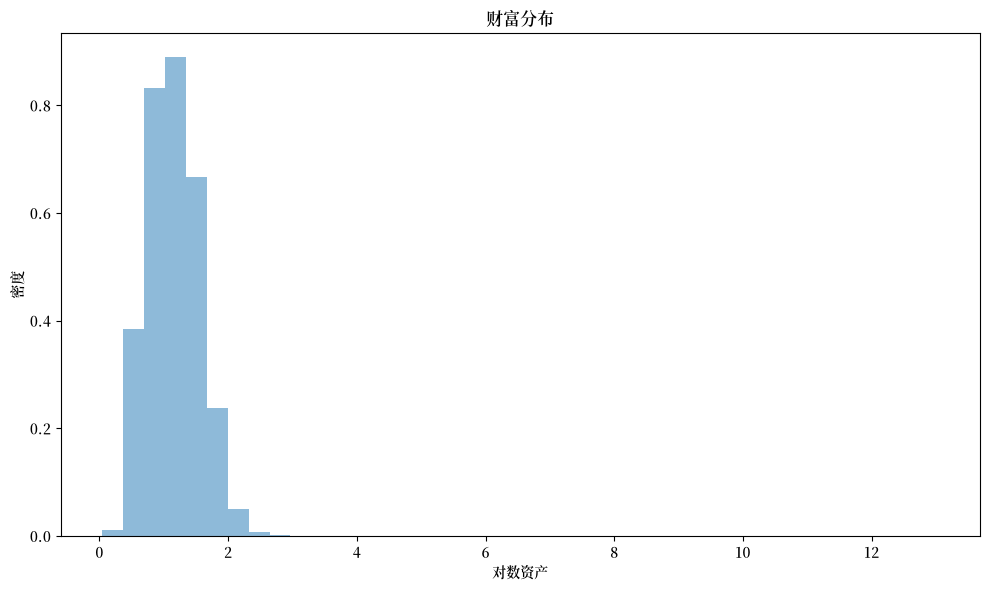

In [13]:
ifp = create_ifp()
# 提取用于初始化的参数
s_grid = ifp.s_grid
n_z = len(ifp.P)
a_init = s_grid[:, None] * jnp.ones(n_z)
c_init = a_init
a_vec, c_vec = solve_model(ifp, a_init, c_init)
assets = compute_asset_stationary(c_vec, a_vec, ifp, num_households=200_000)

# 为图形计算基尼系数
gini_plot = gini_coefficient(assets)

# 绘制对数财富直方图
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(jnp.log(assets), bins=40, alpha=0.5, density=True)
ax.set(xlabel='对数资产', ylabel='密度', title="财富分布")
plt.tight_layout()
plt.show()

直方图显示了对数财富的分布。

请记住我们看的是对数值，直方图表明分布有较长的右尾。

下面我们更详细地研究这一点。

## 财富不平等

让我们通过计算这一现象的一些标准度量来考察财富不平等。

我们还将考察不平等程度如何随利率变化。

### 度量不平等

让我们打印出模拟结果中的基尼系数和前 1% 财富份额：

In [14]:
gini = gini_coefficient(assets)
top1 = top_share(assets, p=0.01)

print(f"基尼系数：{gini:.4f}")
print(f"前 1% 财富份额：{top1:.4f}")

基尼系数：0.7847
前 1% 财富份额：0.7306


最近的数据表明

* 美国财富的基尼系数约为 0.8
* 前 1% 的财富份额超过 0.3

我们具有随机收益的模型生成的基尼系数接近经验值，这表明资本收入风险是财富不平等的一个重要因素。

然而，前 1% 的财富份额过大。

我们的模型需要适当的校准和进一步的工作——我们暂时搁置这些任务。

## 练习

```{exercise}
:label: ifp_advanced_ex1

绘制基尼系数如何随资产收益的波动性变化。

具体而言，计算 `a_r` 从 0.10 到 0.16 变化时的基尼系数（至少使用 5 个不同的值），并绘制结果图。

这告诉我们资本收入风险与财富不平等之间的关系是什么？

```

```{solution-start} ifp_advanced_ex1
:class: dropdown
```

我们对不同的 `a_r` 值进行循环，为每个值求解模型，模拟财富分布，并计算基尼系数。

正在计算不同收益波动性下的基尼系数...

a_r = 0.100...
基尼系数 = 0.1925
a_r = 0.115...
基尼系数 = 0.1992
a_r = 0.130...
基尼系数 = 0.2225
a_r = 0.145...
基尼系数 = 0.3362
a_r = 0.160...
基尼系数 = 0.7847


基尼系数 = 0.1925
a_r = 0.115... 

基尼系数 = 0.1992
a_r = 0.130... 

基尼系数 = 0.2225
a_r = 0.145... 

基尼系数 = 0.3362
a_r = 0.160... 

基尼系数 = 0.7847


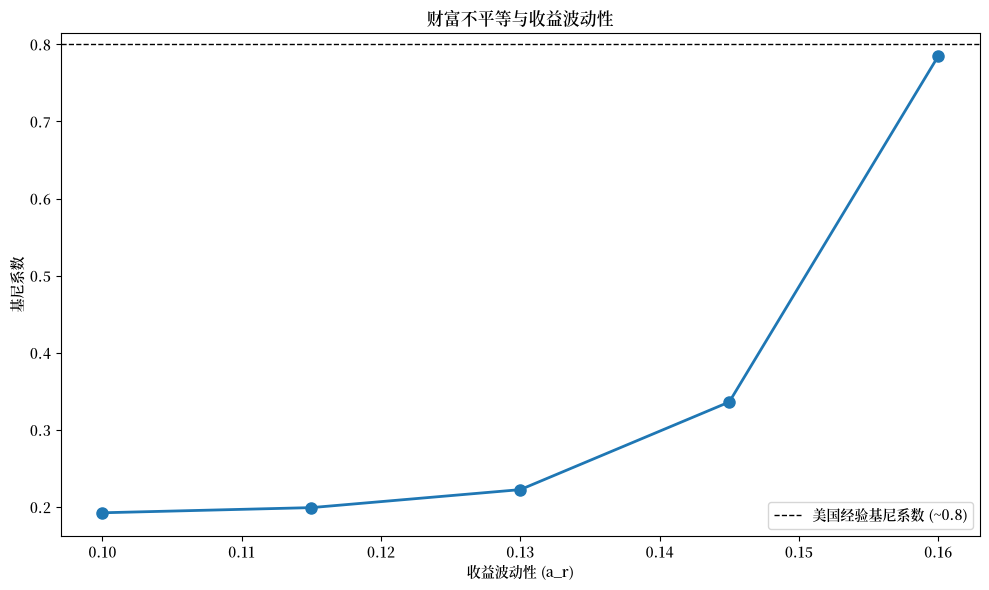

In [15]:
# 需要探索的 a_r 值范围
a_r_vals = np.linspace(0.10, 0.16, 5)
gini_vals = []

print("正在计算不同收益波动性下的基尼系数...\n")

for a_r in a_r_vals:
    print(f"a_r = {a_r:.3f}...", end=" ")

    # 用这个 a_r 值创建模型
    ifp_temp = create_ifp(a_r=a_r, grid_max=100)

    # 求解模型
    s_grid_temp = ifp_temp.s_grid
    n_z_temp = len(ifp_temp.P)
    a_init_temp = s_grid_temp[:, None] * jnp.ones(n_z_temp)
    c_init_temp = a_init_temp
    a_vec_temp, c_vec_temp = solve_model(
        ifp_temp, a_init_temp, c_init_temp
    )

    # 模拟家庭
    assets_temp = compute_asset_stationary(
        c_vec_temp, a_vec_temp, ifp_temp, num_households=200_000
    )

    # 计算基尼系数
    gini_temp = gini_coefficient(assets_temp)
    gini_vals.append(gini_temp)
    print(f"基尼系数 = {gini_temp:.4f}")

# 绘制结果图
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a_r_vals, gini_vals, 'o-', linewidth=2, markersize=8)
ax.set(xlabel='收益波动性 (a_r)',
       ylabel='基尼系数',
       title='财富不平等与收益波动性')
ax.axhline(y=0.8, color='k', linestyle='--', linewidth=1,
           label='美国经验基尼系数 (~0.8)')
ax.legend()
plt.tight_layout()
plt.show()

图中显示，财富不平等（用基尼系数衡量）随收益波动性的增大而增加。

这表明资本收入风险是财富不平等的一个关键驱动因素。

当收益波动性更大时，经历了一系列高收益的幸运家庭会积累远多于不幸家庭的财富，从而导致财富分布的不平等程度加剧。


```{solution-end}
```

```{exercise}
:label: ifp_advanced_ex2

绘制基尼系数如何随劳动收入的波动性变化。

具体而言，计算 `a_y` 从 0.125 到 0.20 变化时的基尼系数，并绘制结果图。在本练习中设置 `a_r=0.10`。

这告诉我们劳动收入风险与财富不平等之间的关系是什么？通过改变劳动收入波动性，我们能否达到与改变收益波动性同样程度的不平等上升？

```

```{solution-start} ifp_advanced_ex2
:class: dropdown
```

我们对不同的 `a_y` 值进行循环，为每个值求解模型，模拟财富分布，并计算基尼系数。

正在计算不同劳动收入波动性下的基尼系数...

a_y = 0.125...
基尼系数 = 0.1787
a_y = 0.144...
基尼系数 = 0.1818
a_y = 0.163...
基尼系数 = 0.1852
a_y = 0.181...
基尼系数 = 0.1887
a_y = 0.200...
基尼系数 = 0.1925


基尼系数 = 0.1787
a_y = 0.144... 

基尼系数 = 0.1818
a_y = 0.163... 

基尼系数 = 0.1852
a_y = 0.181... 

基尼系数 = 0.1887
a_y = 0.200... 

基尼系数 = 0.1925


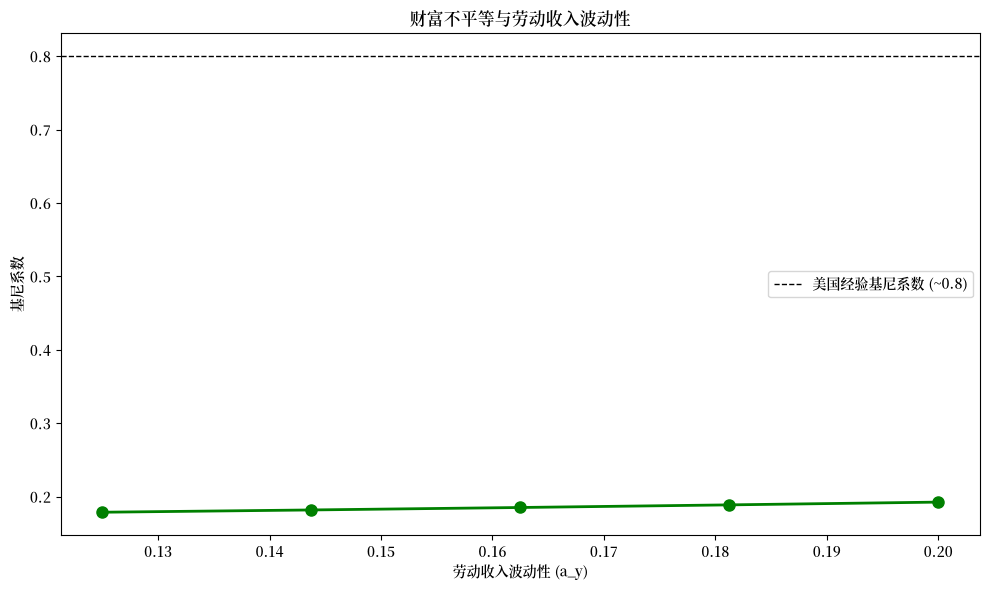

In [16]:
# 需要探索的 a_y 值范围
a_y_vals = np.linspace(0.125, 0.20, 5)
gini_vals_y = []

print("正在计算不同劳动收入波动性下的基尼系数...\n")

for a_y in a_y_vals:
    print(f"a_y = {a_y:.3f}...", end=" ")

    # 用这个 a_y 值和 a_r=0.10 创建模型
    ifp_temp = create_ifp(a_y=a_y, a_r=0.10, grid_max=100)

    # 求解模型
    s_grid_temp = ifp_temp.s_grid
    n_z_temp = len(ifp_temp.P)
    a_init_temp = s_grid_temp[:, None] * jnp.ones(n_z_temp)
    c_init_temp = a_init_temp
    a_vec_temp, c_vec_temp = solve_model(
        ifp_temp, a_init_temp, c_init_temp
    )

    # 模拟家庭
    assets_temp = compute_asset_stationary(
        c_vec_temp, a_vec_temp, ifp_temp, num_households=200_000
    )

    # 计算基尼系数
    gini_temp = gini_coefficient(assets_temp)
    gini_vals_y.append(gini_temp)
    print(f"基尼系数 = {gini_temp:.4f}")

# 绘制结果图
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a_y_vals, gini_vals_y, 'o-', linewidth=2, markersize=8, color='green')
ax.set(xlabel='劳动收入波动性 (a_y)',
       ylabel='基尼系数',
       title='财富不平等与劳动收入波动性')
ax.axhline(y=0.8, color='k', linestyle='--', linewidth=1,
           label='美国经验基尼系数 (~0.8)')
ax.legend()
plt.tight_layout()
plt.show()

图中显示，财富不平等随劳动收入波动性的增大而增加，但这一效应比收益波动性的效应要弱得多。

比较这两个练习：

- 当收益波动性（`a_r`）从 0.10 变化到 0.16 时，基尼系数从约 0.20 急剧上升到 0.79
- 当劳动收入波动性（`a_y`）以类似的百分比幅度从 0.125 变化到 0.20 时，基尼系数虽有增加，但增幅小得多

这表明，相较于劳动收入风险，资本收入风险是财富不平等更重要的驱动因素。

其直觉在于，财富积累会随时间产生复利效应：经历了有利资产收益的家庭可以将这些收益进行再投资，从而实现指数级增长。

相比之下，劳动收入冲击虽然会影响当期消费和储蓄，但对财富积累不具有同样的复利效应。


```{solution-end}
```